In [2]:
#HW 09: hyperspectral unmixing
# Starter code by Jesse Wilson (2024) jesse.wilson@colostate.edu
import torch
from torch import nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from IPython.display import clear_output
from torchvision.transforms.functional import gaussian_blur
import numpy as np
from random import randint
import scipy.io # for reading .mat files
import skimage.io
import random

/top/students/UNGRAD/ECE/ramk/home/pytorch-linuxg4/lib64/python3.6/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
device = torch.device('cuda:1')

(135, 42, 24)


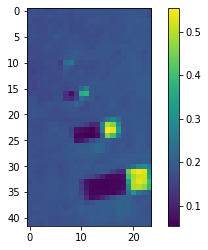

In [4]:
# load a hyperspectral cube
# DLR HySU benchmark https://www.mdpi.com/2072-4292/13/13/2559
# download URL: https://www.dlr.de/en/eoc/about-us/remote-sensing-technology-institute/photogrammetry-and-image-analysis/public-datasets/dlr-hysu
datacube = skimage.io.imread('DLR_HySU/DLR_HySU/HySpex/all_targets/DLR_HySU_HS_all_targets.tif')

# normalize 
datacube = datacube - datacube.min()
datacube = datacube / datacube.max()

print(datacube.shape)
nc,ny,nx = datacube.shape

img = np.mean(datacube,axis=0)
plt.imshow(img)
plt.colorbar()
plt.show()

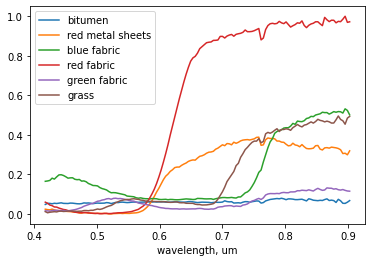

In [5]:
# load corresponding spectral endmember library
# DLR HySU benchmark https://www.mdpi.com/2072-4292/13/13/2559
# download URL: https://www.dlr.de/en/eoc/about-us/remote-sensing-technology-institute/photogrammetry-and-image-analysis/public-datasets/dlr-hysu

dict = np.loadtxt('DLR_HySU/DLR_HySU/spectral_libraries/HySpex_library/DLR_HySU_HS_library_ASCII.txt',
                 skiprows=9)
wl = dict[:,0]
dict = dict[:,1:]

dict = np.concatenate((dict[:,0:5],dict[:,6:]),axis=1)

nwl, ndict = dict.shape

# normalize
dict = dict - dict.min()
dict = dict / dict.max()

plt.plot(wl,dict)
plt.xlabel('wavelength, um')
plt.legend(['bitumen','red metal sheets','blue fabric','red fabric','green fabric','grass'])
    
plt.show()

In [14]:
# Hyperspectral autoencoder CNN
# See Palsson 2021

class HSIautoencoder( nn.Module ):
    def __init__( self ):
        super(HSIautoencoder,self).__init__()

        # define an encoder that estimates abundances from the hyperspectral cube
        # should consist of three Conv2d layers, each followed by leaky relu
        # the first Conv2d should have 3x3 filters (and zero padding); the others should have 1x1 filters
        # the last leaky relu should be followed by softmax applied across the channels
        self.enc = nn.Sequential(
    nn.Conv2d(42, 16, kernel_size=3, stride=1, padding=1),  
    nn.LeakyReLU(negative_slope=0.1),
    nn.Conv2d(16, 32, kernel_size=1, stride=1),  
    nn.LeakyReLU(negative_slope=0.1),
    nn.Conv2d(32, 64, kernel_size=1, stride=1),  
    nn.LeakyReLU(negative_slope=0.1),
    nn.Softmax(dim=1))

        # define a decoder that reconstructs the hyperspectral cube from the abundances
        # should consist of a single Conv2d layer with 1x1 filters, and no bias
        output_channels = datacube.shape[1]  # Match the input channel count
        self.dec = nn.Conv2d(64, output_channels, kernel_size=1, bias=False)# YOUR CODE HERE

        # initialize each of the conv layers using Kaiming's method
        # (double check that encoder layers 0, 2, and 4 correspond to Conv2d filters)
        torch.nn.init.kaiming_uniform_(self.enc[0].weight,nonlinearity='leaky_relu')
        torch.nn.init.kaiming_uniform_(self.enc[2].weight,nonlinearity='leaky_relu')
        torch.nn.init.kaiming_uniform_(self.enc[4].weight,nonlinearity='leaky_relu')

        # trainable scale and offset
        self.scale = nn.Parameter(torch.Tensor([1.0]))
        self.offs = nn.Parameter(torch.Tensor([0.0]))

    def forward( self, x ):
        # pass through the encoder to produce an abundance map
        z = self.enc(x)

        # pass abundances through decoder to reconstruct the data cube
        y = self.scale*self.dec(z)+self.offs

        # return both the abundances and the reconstructed cube
        return z, y
    
    

In [7]:
# pass data through the network, just to check for syntax errors and tensor dimension probelms
net = HSIautoencoder().to(device)
x = torch.Tensor(datacube).to(device).unsqueeze(0)
z,y = net(x)

In [8]:
# function for plotting abundances
def plotAbundances(z):
    n_chan = z.shape[1]  # Number of channels (assuming z has shape [batch_size, n_channels, height, width])
    rows = math.ceil(n_chan / 3)  # Calculate the number of rows needed
    cols = 3  # Set the number of columns to 3 (or adjust as needed)

    plt.figure(figsize=(12, 4 * rows))  # Adjust the figure size based on rows

    for i_chan in range(n_chan):
        img_this_chan = z[0, i_chan].detach().cpu()  # Extract the i-th channel and move it to CPU
        plt.subplot(rows, cols, i_chan + 1)  # Create a subplot for each channel
        plt.imshow(img_this_chan, vmin=0, vmax=img_this_chan.max())  # Adjust the vmin and vmax if necessary
        plt.axis('off')  # Remove axes
        plt.title(f"Channel {i_chan + 1}")

    plt.tight_layout()  # To avoid overlapping subplots
    plt.show()

In [10]:
##### training loop, known endmembers

net = HSIautoencoder().to(device)

# load dictionary onto decoder weights
# you'll need to convert dict to a Tensor and transfer to your GPU
# be careful about tensor dimensionality, using unsqueeze() as needed to adjust
net.dec.weight.data =torch.tensor(dict, dtype=torch.float32).unsqueeze(0).to(device) # YOUR CODE HERE

# set up optimizer on the encoder's parameters (not the decoder)
optimizer = torch.optim.Adam(net.enc.parameters(), lr=1e-3) # YOUR CODE HERE

# set up a mean squared error loss function
loss_fn = torch.nn.MSELoss()# YOUR CODE HERE

loss_train_vec = []

# training loop
n_iters = 10000
for iter in range(1,n_iters):

    # pass the data cube through the network and retrieve the abundance map and reconstructed cube
    z, y = net(torch.tensor(datacube, dtype=torch.float32).to(device))# YOUR CODE HERE

    # evaluate loss
    loss = loss_fn(y, datacube.to(device))# YOUR CODE HERE
  
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    loss_train_vec += [loss.item()]
    
   
    # plot training/validation loss curves
    if iter % 400 == 0:
        clear_output(wait=True)
        
        plotAbundances(z)
        plt.plot(loss_train_vec)
        plt.show()
    

RuntimeError: Expected 4-dimensional input for 4-dimensional weight [16, 135, 3, 3], but got 3-dimensional input of size [135, 42, 24] instead

In [15]:
##### training loop, unknown endmembers (blind unmixing)
# do NOT load dictionary into the decoder this time
# YOUR CODE HERE

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from IPython.display import clear_output

# Initialize the network and move it to GPU or CPU
net = HSIautoencoder().to(device)

# Note: No dictionary is loaded into the decoder for blind unmixing

# Set up optimizer for both encoder and decoder parameters
optimizer = torch.optim.Adam(net.parameters(), lr=1e-3)

# Set up the loss function (MSE loss)
loss_fn = torch.nn.MSELoss()

# Store training loss
loss_train_vec = []

# Training loop
n_iters = 10000
for iter in range(1, n_iters + 1):
    # Forward pass: pass data cube through the network
    datacube_tensor = torch.tensor(datacube, dtype=torch.float32).unsqueeze(0).to(device)  # Add batch dimension
    z, y = net(datacube_tensor) 

    # Compute the loss (MSE between reconstructed cube and the input data cube)
    loss = loss_fn(y, datacube_tensor)

    # Zero the gradients, backpropagate, and update the model
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Record loss
    loss_train_vec.append(loss.item())

    # Plot training loss and abundance maps
    if iter % 400 == 0:
        clear_output(wait=True)
        plotAbundances(z)  
        plt.plot(loss_train_vec, label="Training Loss")
        plt.xlabel("Iteration")
        plt.ylabel("Loss")
        plt.legend()
        plt.show()

RuntimeError: Given groups=1, weight of size [16, 42, 3, 3], expected input[1, 135, 42, 24] to have 42 channels, but got 135 channels instead

#### Blind Unmixing refers to a computational process in hyperspectral imaging where the goal is to decompose a mixed pixel into a set of constituent spectral signatures (endmembers) and their corresponding proportions (abundances) without prior knowledge of the endmembers. Unlike traditional unmixing methods that rely on a predefined library of spectral signatures, blind unmixing aims to discover the endmembers directly from the data

In [5]:
# further analysis here